# Attention Is All You Need - 실습 코드 2: 논문 재현: WMT 번역 데이터로 Transformer 학습

- Tutorial ID: `expand-attention-is-all-you-need`
- Tutorial: Attention Is All You Need
- Section ID: `expand-attention-is-all-you-need-code-2`
- Section: 실습 코드 2: 논문 재현: WMT 번역 데이터로 Transformer 학습


## 이 노트북을 읽는 법

이 노트북은 "정답 코드를 한 번 실행해보고 끝"내는 용도가 아니라, **Attention Is All You Need 논문의 수식이 실제 파이토치(PyTorch) 텐서 연산으로 어떻게 바뀌는지**를 한 줄씩 따라가며 확인하기 위한 실습 노트입니다. 이전 실습(실습 코드 1)에서 어텐션의 기본 개념을 다뤘다면, 이번 실습 코드 2에서는 그 부품들을 모두 조립해서 **인코더-디코더 전체 Transformer**를 만들고, 실제 번역 데이터로 **학습 루프**를 돌려서 손실(loss)이 줄어드는 것까지 직접 확인합니다.

### 학습 목표
1. Q/K/V가 어떤 shape으로 만들어지고, 여러 head로 쪼개졌다가 다시 합쳐지는 과정을 추적합니다.
2. 위치 정보(Positional Encoding)가 sin/cos 값으로 어떻게 만들어지고, 임베딩과 더해지는지 확인합니다.
3. 인코더와 디코더가 어떻게 서로 다른 마스크(mask)를 쓰는지(패딩 마스크 vs. 미래 토큰 마스크) 이해합니다.
4. 논문이 제안한 학습 기법들 — Label Smoothing, Warmup이 있는 학습률 스케줄 — 을 실제 코드로 구현하고 효과를 그래프로 확인합니다.
5. 작은 toy 번역 데이터셋으로 모델을 처음부터 끝까지 학습시키고, 학습된 모델이 문장을 번역하는 과정(추론)까지 직접 실행해 봅니다.

### 진행 순서 (목차)
0. 환경 설정
1. 하이퍼파라미터 — 논문 값 vs. 우리가 쓸 축소판 값
2. 데이터 준비 — WMT 데이터 소개와 toy 영어-독일어 데이터셋
3. Positional Encoding
4. Scaled Dot-Product Attention
5. Multi-Head Attention
6. Position-wise Feed-Forward Network
7. 마스크(Mask) — 패딩 마스크, 미래 토큰 마스크
8. Encoder Layer / Decoder Layer
9. 임베딩 + 인코더/디코더 스택 + 전체 Transformer 모델
10. Label Smoothing
11. Noam Learning Rate Scheduler
12. 학습 루프
13. 실제 학습 실행
14. 추론 — Greedy Decoding으로 번역해보기
15. (보너스) Attention 가중치 시각화
16. 마무리 — toy 실습과 논문의 실제 설정 비교, 다음 단계

### 읽을 때 이렇게 보세요
- 숫자 하나하나를 외우려 하지 말고, **각 연산 직후에 찍히는 shape(텐서 모양)** 과 **정보가 어느 방향으로 흘러가는지**에 집중하세요.
- 코드 셀 바로 위 마크다운 셀에 "왜 이 코드가 필요한지"를 먼저 적어두었습니다. 코드만 보고 막히면 바로 위 설명을 다시 읽어보세요.
- 이 노트북은 **실제로 끝까지 실행 가능**합니다. 다만 진짜 WMT14 데이터(450만 문장 쌍, 수 GB)를 그대로 쓰면 다운로드와 학습에 시간이 오래 걸리므로, 같은 코드 구조를 **직접 만든 아주 작은 영어-독일어 문장 32쌍**으로 1분 안에 검증해볼 수 있도록 구성했습니다. 실제 WMT 데이터로 바꾸는 방법은 2절과 16절에서 안내합니다.
- `torch`나 `matplotlib`가 설치되어 있지 않다면 바로 아래 셀의 주석을 참고하세요. Google Colab에는 보통 기본 설치되어 있습니다.


## 0. 환경 설정

필요한 라이브러리를 불러오고, 실행 결과가 항상 똑같이 재현되도록 random seed를 고정합니다. 그리고 GPU(`cuda`)가 있으면 GPU를, 없으면 CPU를 쓰도록 `device`를 설정합니다.


In [1]:
# 로컬 환경에서 처음 실행한다면 아래 줄의 주석을 풀어서 필요한 패키지를 설치하세요.
# (Google Colab에는 보통 이미 설치되어 있어서 실행하지 않아도 됩니다.)
# !pip install torch matplotlib koreanize-matplotlib

%matplotlib inline

import math                                   # 위치 인코딩 계산에 필요한 sin/cos, log
import random                                  # 재현 가능한 랜덤 시드 고정
from functools import partial                  # DataLoader의 collate_fn에 인자를 미리 채워 넣기 위함

import torch
import torch.nn as nn
import torch.nn.functional as F                # ReLU, softmax 등 함수형 연산
from torch.utils.data import Dataset, DataLoader  # 데이터 파이프라인 구성용
import matplotlib.pyplot as plt                 # 위치 인코딩/학습 곡선 등을 그림으로 확인하기 위함
try:
    import koreanize_matplotlib                # 그래프에서 한국어가 깨지지 않도록 하는 폰트 패키지
except ImportError:
    pass  # 없으면 그냥 넘어감 (그래프 레이블이 □로 보일 수 있음)

# ── 재현성을 위한 시드 고정 ──
# 같은 코드를 다시 실행해도 (거의) 같은 결과가 나오도록 난수의 "시작점"을 고정합니다.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# ── 디바이스 설정 ──
# GPU(cuda)가 있으면 GPU에서, 없으면 CPU에서 계산하도록 자동으로 선택합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


사용 디바이스: cpu


## 1. 하이퍼파라미터 — 논문 값 vs. 우리가 쓸 축소판 값

Transformer를 만들기 전에, 모델의 크기를 결정하는 하이퍼파라미터들을 먼저 정리합니다. 논문 5.1절(Base 모델 기준)이 실제로 사용한 값과, 이 노트북에서 빠르게 학습을 체험해보기 위해 줄인 값을 나란히 적어두었습니다.

| 하이퍼파라미터 | 의미 | 논문 Base 모델 | 이 노트북(toy) |
|---|---|---|---|
| `d_model` | 토큰 하나를 표현하는 벡터의 차원 | 512 | 128 |
| `num_heads` | Multi-Head Attention의 head 개수 | 8 | 4 |
| `d_ff` | Feed-Forward 내부의 은닉 차원 | 2048 | 256 |
| `num_layers` | 인코더/디코더를 쌓는 층 수 (N) | 6 | 2 |
| `dropout` | 드롭아웃 비율 | 0.1 | 0.1 |
| `vocab_size` | 단어사전 크기 (BPE 서브워드 기준) | 약 37,000 | 데이터에서 자동 계산 (수십 개 수준) |
| `warmup_steps` | 학습률 warmup 구간 길이 | 4,000 | 50 (총 학습 스텝 수가 작아서 비례 축소) |

모델 구조(코드)는 두 경우 모두 **완전히 동일**합니다. 단지 "숫자"만 다릅니다. 이 사실 자체가 Transformer 구조의 장점 중 하나입니다 — 같은 코드로 작은 모델도, 논문처럼 거대한 모델도 만들 수 있습니다.


In [2]:
# 이 노트북에서 실제로 사용할 값 (빠른 실습을 위한 축소판)
D_MODEL = 128        # 논문 기준 512
NUM_HEADS = 4         # 논문 기준 8   (head 하나당 차원 d_k = d_model / num_heads)
D_FF = 256            # 논문 기준 2048
NUM_LAYERS = 2         # 논문 기준 6
DROPOUT = 0.1
MAX_LEN = 100         # 문장의 최대 길이 (Positional Encoding 표를 미리 이 길이만큼 만들어 둠)
WARMUP_STEPS = 50     # 논문 기준 4000 (총 학습 스텝 수 자체가 작으므로 비례해서 줄임)

assert D_MODEL % NUM_HEADS == 0, "d_model은 num_heads로 나누어 떨어져야 head별 차원(d_k)이 정수가 됩니다."
print(f"head 하나당 차원 d_k = d_model({D_MODEL}) / num_heads({NUM_HEADS}) = {D_MODEL // NUM_HEADS}")


head 하나당 차원 d_k = d_model(128) / num_heads(4) = 32


## 2. 데이터 준비

### WMT가 무엇인가요?
WMT(Workshop on Machine Translation)는 매년 열리는 기계번역 학회 겸 경진대회로, 여기서 공개하는 영어-독일어(En-De), 영어-프랑스어(En-Fr) 등의 대규모 병렬 말뭉치(같은 의미의 문장을 두 언어로 나란히 적어 둔 데이터)가 기계번역 연구의 표준 벤치마크로 널리 쓰입니다. 논문은 정확히 **WMT 2014 영어-독일어 데이터셋(약 450만 문장 쌍)** 으로 학습했고, 단어를 그대로 쓰지 않고 **BPE(Byte Pair Encoding)** 라는 서브워드(subword) 토큰화로 약 37,000개 크기의 공유 단어사전을 만들어 사용했습니다.

### 왜 이 노트북에서는 진짜 WMT 데이터를 쓰지 않나요?
- 실제 WMT14 En-De 데이터는 수 GB 크기이고, 받아서 정제(cleaning)하고 BPE를 학습시키는 과정만 해도 시간이 꽤 걸립니다.
- 논문 기준 모델은 8개의 GPU로 12시간(Base)~3.5일(Big)을 학습합니다. 실습 노트북에서 처음부터 그대로 따라 하기에는 비현실적입니다.

그래서 이 노트북에서는 **모델 구조와 학습 파이프라인(코드)은 논문과 동일하게 두고, 데이터만 아주 작게** 만듭니다. 직접 만든 영어→독일어 문장 32쌍으로 같은 코드가 "정말로 작동하는지" 1분 안에 확인하는 것이 목표입니다. 이 toy 데이터를 실제 WMT 데이터로 교체하는 방법은 이 절의 마지막과 16절에서 안내합니다.

> toy 데이터인 만큼 문장 수가 적어서, 모델이 "일반화"하기보다는 "암기"에 가깝게 학습됩니다. 이 차이는 14절(추론)에서 직접 확인합니다 — 학습에 쓰인 문장은 잘 번역하지만, 한 번도 보지 못한 새로운 조합의 문장은 잘 틀립니다. 이것이 바로 논문이 450만 문장이라는 방대한 데이터를 쓴 이유입니다.


In [3]:
# 영어 -> 독일어 toy 병렬 문장 32쌍
# (실제 WMT 데이터와 같은 "영어-독일어 번역" 과제이지만, 직접 만든 아주 작은 예시 데이터입니다)
pairs = [
    ("I am a student", "Ich bin ein Student"),
    ("You are my friend", "Du bist mein Freund"),
    ("He is a teacher", "Er ist ein Lehrer"),
    ("She is a doctor", "Sie ist eine Aerztin"),
    ("We are happy", "Wir sind gluecklich"),
    ("They are students", "Sie sind Studenten"),
    ("I love you", "Ich liebe dich"),
    ("I like coffee", "Ich mag Kaffee"),
    ("I like tea", "Ich mag Tee"),
    ("She likes music", "Sie mag Musik"),
    ("He likes books", "Er mag Buecher"),
    ("The cat is small", "Die Katze ist klein"),
    ("The dog is big", "Der Hund ist gross"),
    ("The sky is blue", "Der Himmel ist blau"),
    ("The sun is bright", "Die Sonne ist hell"),
    ("I have a book", "Ich habe ein Buch"),
    ("You have a car", "Du hast ein Auto"),
    ("We have a house", "Wir haben ein Haus"),
    ("I eat an apple", "Ich esse einen Apfel"),
    ("She eats bread", "Sie isst Brot"),
    ("He drinks water", "Er trinkt Wasser"),
    ("I drink coffee", "Ich trinke Kaffee"),
    ("The weather is nice", "Das Wetter ist schoen"),
    ("Today is Monday", "Heute ist Montag"),
    ("Tomorrow is Tuesday", "Morgen ist Dienstag"),
    ("I go to school", "Ich gehe zur Schule"),
    ("You go to work", "Du gehst zur Arbeit"),
    ("We go to the park", "Wir gehen zum Park"),
    ("I see a bird", "Ich sehe einen Vogel"),
    ("She sees a tree", "Sie sieht einen Baum"),
    ("I read a book", "Ich lese ein Buch"),
    ("He writes a letter", "Er schreibt einen Brief"),
]

print(f"문장 쌍 개수: {len(pairs)}")
print("예시:", pairs[0])

# 참고: 독일어 움라우트(a", o", u", ss)는 노트북 환경 간 인코딩 문제를 피하려고
#       ae/oe/ue/ss 로 풀어 썼습니다 (예: schoen = schön). 실제 데이터에서는 원래 문자를 그대로 쓰면 됩니다.


문장 쌍 개수: 32
예시: ('I am a student', 'Ich bin ein Student')


### 토큰화(Tokenization)와 단어사전(Vocabulary)

신경망은 "I like coffee" 라는 글자 자체를 이해하지 못합니다. 다음 두 단계를 거쳐 **정수 인덱스의 나열**로 바꿔야 합니다.

1. **토큰화**: 문장을 의미 있는 작은 단위(토큰)로 쪼갭니다. 논문은 BPE라는 서브워드 단위를 쓰지만(예: "playing" → "play" + "ing"), 이 노트북에서는 이해하기 쉽도록 **공백 기준 단어 단위**로 간단히 쪼갭니다. (예: "I like coffee" → ["i", "like", "coffee"])
2. **단어사전(vocab) 구축**: 데이터에 등장하는 모든 토큰에 고유한 정수 번호를 매깁니다. 그리고 다음 4개의 **특수 토큰**을 항상 맨 앞에 추가합니다.

| 특수 토큰 | 역할 |
|---|---|
| `<pad>` | 배치 안에서 문장 길이를 맞추기 위한 채움(padding) 토큰. attention 계산에서 무시되어야 함 |
| `<sos>` | 문장의 시작(Start Of Sentence). 디코더가 "여기서부터 생성을 시작하라"는 신호로 사용 |
| `<eos>` | 문장의 끝(End Of Sentence). 디코더가 "여기서 생성을 멈춰라"는 신호로 사용 |
| `<unk>` | 단어사전에 없는, 처음 보는 단어(Unknown)를 대신 표시 |

> 실제 BPE/서브워드 토큰화를 쓰면 `<unk>`가 거의 발생하지 않는다는 장점이 있습니다 (어떤 단어든 더 작은 조각들의 조합으로 표현 가능하기 때문). 단어 단위 토큰화는 학습 데이터에 없던 단어를 만나면 전부 `<unk>`로 처리된다는 한계가 있습니다 — 이 역시 실제 시스템이 서브워드 토큰화를 쓰는 이유 중 하나입니다.


In [4]:
def tokenize(text):
    """아주 단순한 토큰화: 소문자로 바꾸고 공백 기준으로 쪼갭니다."""
    return text.lower().split()


def build_vocab(sentences):
    """문장 리스트를 받아 {토큰: 정수 인덱스} 사전을 만듭니다."""
    specials = ['<pad>', '<sos>', '<eos>', '<unk>']
    vocab = {tok: idx for idx, tok in enumerate(specials)}  # 특수 토큰을 0~3번에 고정 배치

    for sent in sentences:
        for tok in tokenize(sent):
            if tok not in vocab:
                vocab[tok] = len(vocab)   # 새 토큰이면 사전 맨 뒤에 새 번호를 매김
    return vocab


# 영어 문장들로 영어 단어사전을, 독일어 문장들로 독일어 단어사전을 각각 만듭니다.
# (논문은 두 언어가 같은 단어사전을 공유하지만, 여기서는 이해하기 쉽도록 따로 만듭니다)
src_vocab = build_vocab([en for en, de in pairs])
tgt_vocab = build_vocab([de for en, de in pairs])
PAD_IDX = src_vocab['<pad>']
assert src_vocab['<pad>'] == tgt_vocab['<pad>'] == 0   # 두 사전 모두 <pad>를 0번으로 고정해 두었으므로 항상 성립

print(f"영어(src) 단어사전 크기: {len(src_vocab)}")
print(f"독일어(tgt) 단어사전 크기: {len(tgt_vocab)}")
print("토큰화 예시:", tokenize("I like coffee"), "->",
      [src_vocab[t] for t in tokenize("I like coffee")])


영어(src) 단어사전 크기: 67
독일어(tgt) 단어사전 크기: 75
토큰화 예시: ['i', 'like', 'coffee'] -> [4, 22, 23]


### Dataset과 DataLoader, 그리고 패딩(Padding)

PyTorch는 데이터를 `Dataset`(개별 샘플을 어떻게 가져올지 정의)과 `DataLoader`(샘플들을 배치로 묶어주는 역할), 두 단계로 다룹니다.

문장마다 길이가 다르기 때문에, 같은 배치 안의 문장들은 **가장 긴 문장 기준으로 짧은 문장 뒤에 `<pad>` 토큰을 채워서** 길이를 맞춰야 행렬 연산(텐서 연산)이 가능합니다. 이 "길이 맞추기"를 `collate_fn`(배치를 어떻게 모을지 정의하는 함수)에서 처리합니다.

또한 인코더 입력(source)과 디코더 입력/정답(target)에 특수 토큰을 붙이는 방식이 다릅니다.
- **source(영어)**: 문장 끝에 `<eos>`만 붙입니다. (인코더는 문장 전체를 한 번에 보므로 `<sos>`가 필요 없습니다)
- **target(독일어)**: 맨 앞에 `<sos>`, 맨 뒤에 `<eos>`를 붙입니다. (디코더는 `<sos>`부터 한 토큰씩 다음 단어를 예측해 나가야 하기 때문입니다 — 12절 학습 루프에서 자세히 다룹니다)


In [5]:
class TranslationDataset(Dataset):
    """(영어 문장, 독일어 문장) 쌍의 리스트를 정수 텐서 쌍으로 바꿔주는 Dataset"""

    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def encode(self, sentence, vocab, add_sos, add_eos):
        ids = [vocab.get(tok, vocab['<unk>']) for tok in tokenize(sentence)]
        if add_sos:
            ids = [vocab['<sos>']] + ids
        if add_eos:
            ids = ids + [vocab['<eos>']]
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        src_sent, tgt_sent = self.pairs[idx]
        src_ids = self.encode(src_sent, self.src_vocab, add_sos=False, add_eos=True)
        tgt_ids = self.encode(tgt_sent, self.tgt_vocab, add_sos=True, add_eos=True)
        return src_ids, tgt_ids


def collate_fn(batch, pad_idx):
    """배치 안에서 가장 긴 문장 기준으로, 짧은 문장 뒤를 <pad>로 채워서 길이를 맞춥니다."""
    src_batch, tgt_batch = zip(*batch)
    src_batch = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=pad_idx)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=pad_idx)
    return src_batch, tgt_batch


dataset = TranslationDataset(pairs, src_vocab, tgt_vocab)
collate = partial(collate_fn, pad_idx=PAD_IDX)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate)

# 배치 하나를 직접 꺼내서 shape을 확인해 봅니다.
sample_src, sample_tgt = next(iter(train_loader))
print("sample_src shape:", sample_src.shape, " # (batch_size, src_seq_len)")
print("sample_tgt shape:", sample_tgt.shape, " # (batch_size, tgt_seq_len)")
print("\nsrc 첫 문장 (정수 인덱스):", sample_src[0].tolist())
print("tgt 첫 문장 (정수 인덱스):", sample_tgt[0].tolist())


sample_src shape: torch.Size([8, 5])  # (batch_size, src_seq_len)
sample_tgt shape: torch.Size([8, 6])  # (batch_size, tgt_seq_len)

src 첫 문장 (정수 인덱스): [4, 5, 6, 7, 2]
tgt 첫 문장 (정수 인덱스): [1, 4, 5, 6, 7, 2]


### 참고: 실제 WMT 데이터로 바꾸려면?

아래는 **실행하지 않는 참고 코드**입니다. 위 toy 데이터를 실제 WMT14 영어-독일어 데이터로 바꾸고 싶다면, Hugging Face `datasets` 라이브러리를 활용해 아래와 비슷한 방식으로 시작할 수 있습니다 (최신 사용법은 라이브러리 공식 문서를 확인하세요).

```python
# pip install datasets sentencepiece
from datasets import load_dataset

wmt = load_dataset("wmt14", "de-en")   # 약 450만 문장 쌍, 다운로드 용량이 큽니다
train_pairs = [(ex["en"], ex["de"]) for ex in wmt["train"]["translation"]]

# 실제 시스템에서는 위 build_vocab() 대신 BPE/서브워드 토크나이저를 학습시켜 사용합니다.
# 예: SentencePiece, Hugging Face tokenizers 라이브러리 등
```

실제 데이터로 바꾸더라도, **이 노트북에서 만든 `Transformer`, `MultiHeadAttention` 등 모델 코드는 그대로** 재사용할 수 있습니다 — `vocab_size`, `d_model` 같은 하이퍼파라미터만 논문 기준 값(37000, 512 등)으로 키워주면 됩니다.


## 3. Positional Encoding (논문 3.5절)

### 왜 위치 정보가 따로 필요할까요?
RNN은 토큰을 한 개씩 순서대로 처리하기 때문에 "지금이 몇 번째 토큰인지"를 구조적으로 알고 있습니다. 하지만 Self-Attention은 모든 토큰을 **동시에, 서로 동등하게** 비교합니다 — 토큰들의 "집합(set)"을 보는 것과 비슷해서, 순서를 섞어도 attention 계산 자체는 똑같이 동작합니다. 즉, "나는 너를 사랑해"와 "사랑해 너를 나는"을 attention 혼자서는 구분하지 못합니다.

그래서 각 위치(0번째, 1번째, 2번째, ...)마다 고유한 벡터를 만들어 **입력 임베딩에 더해주는 방식**으로 순서 정보를 "주입"합니다. 이것이 Positional Encoding입니다.

### 공식 (논문 식 1, 2)

$$PE_{(pos,\ 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right) \qquad PE_{(pos,\ 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- `pos`: 토큰의 위치 (0, 1, 2, ...)
- `i`: 임베딩 차원의 인덱스 (0 ~ d_model/2 - 1). 짝수 차원에는 sin, 홀수 차원에는 cos을 사용합니다.

말로 풀면: **차원마다 서로 다른 주기(frequency)를 가진 sin/cos 파동**을 만들어 둔다고 생각하면 됩니다. 차원 인덱스가 낮을수록 빠르게 진동하고, 높을수록 천천히 진동합니다. 시계의 시침·분침·초침을 같이 보면 정확한 시각을 알 수 있듯, 여러 주기를 조합해서 각 위치를 고유하게 표현하는 방식입니다.

논문은 이 방식을 택한 이유로, 고정된 오프셋 k에 대해 $PE_{pos+k}$가 $PE_{pos}$의 선형 함수로 표현될 수 있어서 모델이 "상대적인 위치 관계"를 더 쉽게 학습할 수 있을 것이라고 설명합니다.


In [6]:
class PositionalEncoding(nn.Module):
    """
    논문 3.5절 Positional Encoding.
    학습되는 파라미터가 아니라, 미리 수학 공식으로 계산해 둔 "고정된 표"를 사용합니다.
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # (max_len, d_model) 크기의 빈 표를 만든 뒤 값을 채워나갑니다.
        pe = torch.zeros(max_len, d_model)

        # position: [[0], [1], [2], ..., [max_len-1]] 모양 (max_len, 1)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # div_term: 10000^(2i/d_model)의 "역수"를 미리 계산해 둠
        # (지수/로그를 이용해 큰 거듭제곱을 안정적으로 계산하는 트릭입니다)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스(0,2,4,...) 차원
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스(1,3,5,...) 차원

        # (max_len, d_model) -> (1, max_len, d_model)
        # 배치 차원을 하나 추가해서, 나중에 (batch, seq, d_model) 입력에 브로드캐스팅으로 더할 수 있게 함
        pe = pe.unsqueeze(0)

        # register_buffer: 학습 대상(파라미터)은 아니지만, model.to(device) 할 때 같이 옮겨지고
        # 저장/로드 시에도 함께 저장되는 텐서로 등록합니다.
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # 미리 만들어둔 표에서 실제 입력 길이(seq_len)만큼만 잘라서 더해줍니다.
        x = x + self.pe[:, :x.size(1)]
        # 논문 5.4절: 임베딩과 위치 인코딩을 더한 결과에 dropout을 적용합니다.
        return self.dropout(x)


# ── 작은 예시로 동작 확인 (이후 실제 모델에 쓰일 D_MODEL=128이 아니라,
#     shape 변화를 눈으로 보기 쉽도록 일부러 작은 차원(16)을 사용합니다) ──
pe_demo = PositionalEncoding(d_model=16, max_len=50, dropout=0.0)
toy_input = torch.zeros(1, 10, 16)   # (batch=1, seq_len=10, d_model=16) 인 "빈" 임베딩
pe_output = pe_demo(toy_input)
print("입력 shape:", toy_input.shape)
print("출력 shape:", pe_output.shape, " # 입력과 동일한 shape (각 위치에 고유 벡터를 '더하기'만 했으므로)")
print("\n0번째 위치의 PE 벡터(앞 8개 차원):", pe_output[0, 0, :8].detach().numpy().round(3))
print("1번째 위치의 PE 벡터(앞 8개 차원):", pe_output[0, 1, :8].detach().numpy().round(3))


입력 shape: torch.Size([1, 10, 16])
출력 shape: torch.Size([1, 10, 16])  # 입력과 동일한 shape (각 위치에 고유 벡터를 '더하기'만 했으므로)

0번째 위치의 PE 벡터(앞 8개 차원): [0. 1. 0. 1. 0. 1. 0. 1.]
1번째 위치의 PE 벡터(앞 8개 차원): [0.841 0.54  0.311 0.95  0.1   0.995 0.032 1.   ]


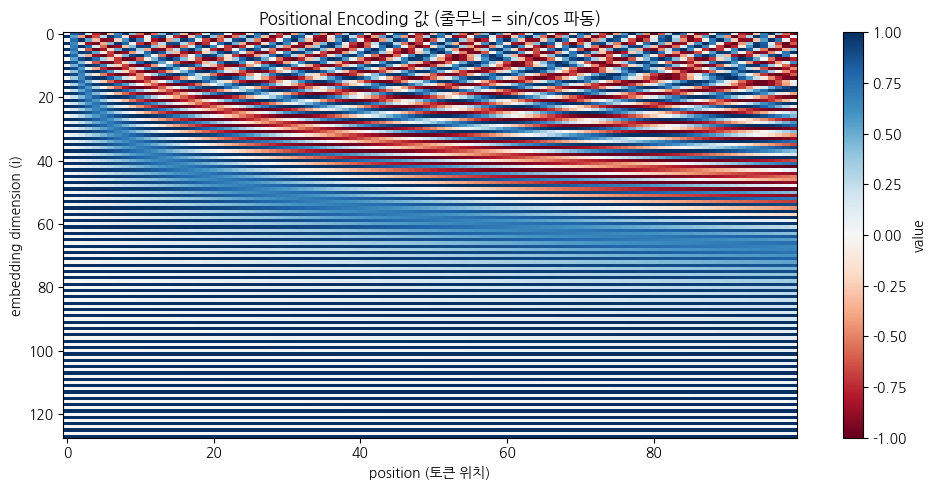

In [7]:
# Positional Encoding을 히트맵으로 시각화 — 가로축: 위치(position), 세로축: 임베딩 차원
pe_viz = PositionalEncoding(d_model=128, max_len=100, dropout=0.0)
pe_matrix = pe_viz.pe[0].numpy()   # (max_len, d_model)

plt.figure(figsize=(10, 5))
plt.imshow(pe_matrix.T, cmap="RdBu", aspect="auto")
plt.xlabel("position (토큰 위치)")
plt.ylabel("embedding dimension (i)")
plt.title("Positional Encoding 값 (줄무늬 = sin/cos 파동)")
plt.colorbar(label="value")
plt.tight_layout()
plt.show()


위 히트맵에서 **가로로 갈수록(위치가 커질수록) 줄무늬가 반복**되는 것을 볼 수 있습니다. 차원 인덱스가 낮은 곳(위쪽)은 줄무늬 간격이 좁고(빠르게 진동), 차원 인덱스가 높은 곳(아래쪽)은 간격이 넓습니다(천천히 진동). 이 서로 다른 주기들의 조합이 각 위치마다 고유한 "지문(fingerprint)"을 만들어 줍니다.


## 4. Scaled Dot-Product Attention (논문 3.2.1절)

### 비유로 먼저 이해하기
도서관에서 책을 찾는 상황을 떠올려 보세요.
- **Query(질문)**: "나는 OO에 대한 책이 필요해" — 내가 지금 찾고 싶은 것
- **Key(색인표)**: 서가에 꽂힌 책마다 붙어있는 "이 책은 OO를 다룹니다"라는 색인 태그
- **Value(실제 내용물)**: 각 책의 실제 본문 내용

나의 Query를 모든 책의 Key와 하나씩 비교해서 "얼마나 관련 있는지" 점수를 매기고, 점수가 높은 책의 Value(내용)를 더 많이 반영해서 최종 답을 만듭니다. 즉 **"관련도 점수로 가중치를 매긴, Value들의 가중 평균"** 이 attention의 출력입니다.

### 공식 (논문 식 1)

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_k}}\right) V$$

단계별로 풀면:
1. **$QK^T$ (내적)**: Query와 Key를 행렬곱해서 "둘이 얼마나 비슷한 방향을 가리키는지" 점수(score)를 계산합니다.
2. **$/\sqrt{d_k}$ (스케일링)**: $d_k$(Key 벡터의 차원)가 커지면 내적 값의 크기도 같이 커지는 경향이 있습니다. 값이 너무 커지면 다음 단계의 softmax가 한쪽으로 치우쳐(거의 0 아니면 거의 1) 그래디언트가 거의 사라지는 문제가 생길 수 있습니다. 이를 막기 위해 $\sqrt{d_k}$로 나눠 점수의 크기를 적당히 눌러줍니다.
3. **softmax**: 점수들을 "합이 1인 확률분포"로 바꿉니다 — 이게 바로 attention 가중치입니다.
4. **가중치 x V**: attention 가중치로 Value들을 가중합(weighted sum)해서 최종 출력을 만듭니다.

### 마스크(mask)는 왜 필요한가요?
경우에 따라 "보면 안 되는" 위치가 있습니다 (예: `<pad>` 토큰, 혹은 디코더에서 아직 생성되지 않은 미래 토큰). 그런 위치는 softmax를 적용하기 *직전*에 매우 작은 값($-\infty$)으로 바꿔둡니다. $-\infty$는 softmax를 거치면 거의 0에 가까운 확률이 되어, 사실상 "그 위치는 무시"하는 효과를 냅니다.


In [8]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    """
    Args:
        query: (batch, num_heads, seq_len_q, d_k)
        key:   (batch, num_heads, seq_len_k, d_k)
        value: (batch, num_heads, seq_len_k, d_v)   # 보통 d_k == d_v
        mask:  (batch, 1, seq_len_q 또는 1, seq_len_k) - True/1인 곳만 보고, False/0인 곳은 무시
    Returns:
        output: (batch, num_heads, seq_len_q, d_v)             - attention을 거친 결과
        attn:   (batch, num_heads, seq_len_q, seq_len_k)        - attention 가중치 (분석/시각화용)
    """
    d_k = query.size(-1)

    # 1) Q와 K의 내적으로 "유사도 점수" 계산 + 스케일링
    #    (batch, heads, seq_q, d_k) @ (batch, heads, d_k, seq_k) -> (batch, heads, seq_q, seq_k)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # 2) 마스킹: 보면 안 되는 위치를 -inf로 채움
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # 3) softmax로 "합이 1인 가중치"로 변환
    attn = F.softmax(scores, dim=-1)

    if dropout is not None:
        attn = dropout(attn)

    # 4) 가중치로 Value를 가중합
    output = torch.matmul(attn, value)
    return output, attn


# ── 작은 숫자로 동작 확인 (head=1개, 문장 길이 5, 차원 8인 임의의 Q/K/V) ──
torch.manual_seed(0)
q_demo = torch.randn(1, 1, 5, 8)   # (batch=1, heads=1, seq_len=5, d_k=8)
k_demo = torch.randn(1, 1, 5, 8)
v_demo = torch.randn(1, 1, 5, 8)

out_demo, attn_demo = scaled_dot_product_attention(q_demo, k_demo, v_demo)
print("output shape:", out_demo.shape)
print("attn shape:  ", attn_demo.shape, " # (batch, heads, seq_q, seq_k)")
print("\nattention 가중치 (행마다 합이 1이 되는 확률분포):")
print(attn_demo[0, 0].detach().numpy().round(3))
print("\n각 행의 합 (모두 1.0 이어야 함):", attn_demo[0, 0].sum(dim=-1).detach().numpy().round(3))


output shape: torch.Size([1, 1, 5, 8])
attn shape:   torch.Size([1, 1, 5, 5])  # (batch, heads, seq_q, seq_k)

attention 가중치 (행마다 합이 1이 되는 확률분포):
[[0.615 0.069 0.021 0.038 0.256]
 [0.475 0.114 0.068 0.155 0.188]
 [0.043 0.405 0.059 0.353 0.139]
 [0.097 0.241 0.104 0.353 0.206]
 [0.062 0.156 0.247 0.494 0.041]]

각 행의 합 (모두 1.0 이어야 함): [1. 1. 1. 1. 1.]


## 5. Multi-Head Attention (논문 3.2.2절)

### head를 여러 개 쓰는 이유
하나의 attention만 사용하면, 모든 토큰 쌍의 관계를 **딱 한 가지 기준**으로만 바라보게 됩니다. 여러 개의 head를 사용하면, 각 head가 서로 다른 부분공간(subspace)에서 **서로 다른 종류의 관계**를 따로 학습할 수 있습니다 (예: 어떤 head는 문법적으로 가까운 단어에, 다른 head는 의미적으로 관련된 단어에 더 집중하는 식으로 — 실제로 어떤 패턴을 학습할지는 데이터로부터 모델이 스스로 찾아냅니다).

### 동작 방식
1. 입력을 $d_{model}$ 차원으로 선형 변환해 Q, K, V를 만듭니다.
2. 이 Q, K, V를 `num_heads`개로 "쪼갭니다". $d_{model} = \text{num\_heads} \times d_k$ 관계가 성립합니다 (논문 기준: $512 = 8 \times 64$).
3. **head마다 따로** Scaled Dot-Product Attention을 수행합니다.
4. 모든 head의 결과를 다시 이어붙이고(concat), 마지막으로 한 번 더 선형 변환($W^O$)합니다.

### 공식 (논문 식 2, 3)

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W^O \qquad \text{head}_i = \text{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

### Self-Attention vs. Cross-Attention
Multi-Head Attention 클래스 자체는 동일하지만, **Q/K/V를 어디서 가져오느냐**에 따라 역할이 달라집니다.
- **Self-Attention**: Q, K, V가 모두 같은 곳(같은 문장)에서 나옵니다. "문장 내부의 단어들끼리 서로 어떻게 관련 있는지"를 봅니다. (인코더, 그리고 디코더의 첫 번째 sub-layer)
- **Cross-Attention**: Q는 디코더에서, K/V는 인코더의 출력에서 가져옵니다. "지금 만들고 있는 번역문이 원문의 어느 부분과 관련 있는지"를 봅니다. (디코더의 두 번째 sub-layer)


In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads   # head 하나가 담당하는 차원 크기

        # Q, K, V를 만드는 선형 변환. 구현에서는 d_model -> d_model로 한 번에 계산한 뒤
        # head 개수만큼 "쪼개는" 방식이 일반적입니다 (head별 행렬을 따로 두는 것과 수학적으로 동일).
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)   # 마지막 W^O: head들을 합친 뒤 한 번 더 투영

        self.dropout = nn.Dropout(dropout)
        self.attn = None   # 마지막 forward에서 계산된 attention 가중치를 저장 (15절 시각화에서 사용)

    def split_heads(self, x, batch_size):
        # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, d_k) -> (batch, num_heads, seq_len, d_k)
        # head별로 attention을 독립적으로 계산하기 편하도록 차원 순서를 바꿉니다.
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1) 선형 투영 + head로 분할
        q = self.split_heads(self.w_q(query), batch_size)   # (batch, heads, seq_q, d_k)
        k = self.split_heads(self.w_k(key), batch_size)     # (batch, heads, seq_k, d_k)
        v = self.split_heads(self.w_v(value), batch_size)   # (batch, heads, seq_k, d_k)

        # 2) head별로 Scaled Dot-Product Attention 수행 (4절에서 만든 함수 재사용)
        x, self.attn = scaled_dot_product_attention(q, k, v, mask=mask, dropout=self.dropout)
        # x: (batch, heads, seq_q, d_k)

        # 3) head들을 다시 하나로 합치기 (concat)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        # x: (batch, seq_q, d_model)

        # 4) 마지막 선형 변환 W^O
        return self.w_o(x), self.attn


# ── 작은 예시로 동작 확인 (self-attention: Q=K=V) ──
mha_demo = MultiHeadAttention(d_model=16, num_heads=4, dropout=0.0)
x_demo = torch.randn(2, 5, 16)   # (batch=2, seq_len=5, d_model=16)
out_demo, attn_demo = mha_demo(x_demo, x_demo, x_demo)

print("입력 shape:            ", x_demo.shape)
print("출력 shape:            ", out_demo.shape, " # 입력과 동일한 (batch, seq_len, d_model)")
print("attention 가중치 shape:", attn_demo.shape, " # (batch, num_heads=4, seq_q, seq_k) - head마다 따로 계산됨")


입력 shape:             torch.Size([2, 5, 16])
출력 shape:             torch.Size([2, 5, 16])  # 입력과 동일한 (batch, seq_len, d_model)
attention 가중치 shape: torch.Size([2, 4, 5, 5])  # (batch, num_heads=4, seq_q, seq_k) - head마다 따로 계산됨


## 6. Position-wise Feed-Forward Network (논문 3.3절)

Attention이 "토큰들 사이의 관계"를 살펴보는 역할이라면, FFN은 **각 토큰 자체의 표현을 한 번 더 비선형적으로 가공**하는 역할을 합니다.

$$\text{FFN}(x) = \max(0,\ xW_1 + b_1)\,W_2 + b_2$$

즉 `Linear -> ReLU -> Linear`로 이루어진 단순한 2층 MLP입니다.

"position-wise"(위치별)라는 이름이 붙은 이유: 문장 안의 **모든 위치(토큰)에 동일한 가중치($W_1, W_2$)** 를 적용하기 때문입니다. 위치마다 다른 가중치를 쓰는 게 아니라, 같은 변환을 모든 토큰에 독립적으로 반복 적용합니다 (kernel size가 1인 Conv1d를 두 번 적용하는 것과 동일합니다).

보통 중간 차원 $d_{ff}$는 $d_{model}$보다 훨씬 큽니다 (논문 기준 2048 vs 512). 표현 공간을 한 번 넓혔다가(더 다양한 패턴을 표현할 수 있게) 다시 원래 차원으로 좁히는 구조입니다.


In [10]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=512, d_ff=2048, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)   # d_model -> d_ff (확장)
        self.w_2 = nn.Linear(d_ff, d_model)   # d_ff -> d_model (축소)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, d_model) -> 동일한 shape으로 반환
        return self.w_2(self.dropout(F.relu(self.w_1(x))))


# ── 동작 확인 ──
ffn_demo = PositionwiseFeedForward(d_model=16, d_ff=32, dropout=0.0)
x_demo = torch.randn(2, 5, 16)
out_demo = ffn_demo(x_demo)
print("입력 shape:", x_demo.shape, " (d_model=16)")
print("출력 shape:", out_demo.shape, " # 중간에 32차원으로 늘었다가 다시 16차원으로 돌아옴")


입력 shape: torch.Size([2, 5, 16])  (d_model=16)
출력 shape: torch.Size([2, 5, 16])  # 중간에 32차원으로 늘었다가 다시 16차원으로 돌아옴


## 7. 마스크(Mask) — 패딩 마스크와 미래 토큰(Look-ahead) 마스크

Transformer에는 두 가지 목적의 마스크가 필요합니다.

### (1) 패딩 마스크 (Padding Mask)
배치를 만들 때 짧은 문장 뒤에 채워 넣은 `<pad>` 토큰은 아무 의미가 없는 "채움"일 뿐입니다. 이 위치를 Key로 사용해서 attention을 계산하면 안 되므로, `<pad>` 위치는 항상 마스킹(무시)합니다. 인코더, 디코더 모두에서 사용됩니다.

### (2) 미래 토큰 마스크 (Look-ahead / Causal Mask)
디코더는 **자기회귀적(autoregressive)** 으로 동작해야 합니다 — 즉, $i$번째 단어를 생성할 때는 $1 \sim i-1$번째까지 생성된 단어만 보고, $i+1$번째 이후의 "미래" 단어는 보면 안 됩니다. 학습할 때는 정답 문장 전체를 한 번에 입력으로 넣는 **teacher forcing** 기법을 쓰는데(12절에서 자세히 설명), 이때 디코더가 실수로 미래 정답을 "커닝"하지 못하도록 하삼각행렬(lower-triangular) 모양의 마스크를 사용합니다.

예) `seq_len=4`인 경우 causal mask:
```
[[1, 0, 0, 0],
 [1, 1, 0, 0],
 [1, 1, 1, 0],
 [1, 1, 1, 1]]
```
1번째 행(=0번째 토큰을 보고 다음을 예측하는 시점)은 0번째 토큰만 볼 수 있고, 4번째 행(=3번째 토큰까지 본 시점)은 0~3번째 토큰을 모두 볼 수 있습니다.

디코더의 self-attention에서는 이 **두 마스크를 동시에(AND 조건으로)** 적용합니다 — `<pad>`도 아니고, 미래 토큰도 아닌 위치만 볼 수 있습니다.


source padding mask shape: torch.Size([8, 1, 1, 5])
target mask shape:         torch.Size([8, 1, 5, 5])


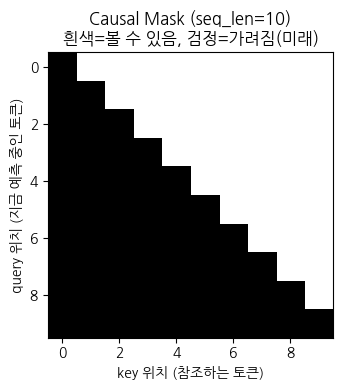

In [11]:
def make_padding_mask(seq, pad_idx):
    """
    seq: (batch, seq_len) 정수 인덱스 텐서
    반환: (batch, 1, 1, seq_len) - <pad>가 아닌 위치는 True, <pad>인 위치는 False
          MultiHeadAttention 내부의 (batch, heads, seq_q, seq_k) 텐서에 브로드캐스팅으로 적용됩니다.
    """
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)


def generate_causal_mask(seq_len):
    """하삼각 마스크: 미래 토큰을 보지 못하게 막음. 반환 shape: (1, 1, seq_len, seq_len)"""
    mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
    return mask.unsqueeze(0).unsqueeze(0)


def make_tgt_mask(tgt, pad_idx):
    """디코더용 마스크 = 패딩 마스크 AND 미래 토큰 마스크 (두 조건을 모두 만족해야 그 위치를 볼 수 있음)"""
    seq_len = tgt.size(1)
    pad_mask = make_padding_mask(tgt, pad_idx)                   # (batch, 1, 1, seq_len)
    causal_mask = generate_causal_mask(seq_len).to(tgt.device)   # (1, 1, seq_len, seq_len)
    return pad_mask & causal_mask                                  # 브로드캐스팅 -> (batch, 1, seq_len, seq_len)


# ── 동작 확인: 2절에서 만든 sample_src, sample_tgt로 실제 shape을 찍어봅니다 ──
demo_src_mask = make_padding_mask(sample_src, PAD_IDX)
demo_tgt_mask = make_tgt_mask(sample_tgt[:, :-1], PAD_IDX)
print("source padding mask shape:", demo_src_mask.shape)
print("target mask shape:        ", demo_tgt_mask.shape)

# causal mask 부분만 그림으로 확인
plt.figure(figsize=(4, 4))
plt.imshow(generate_causal_mask(10)[0, 0].numpy(), cmap="Greys")
plt.title("Causal Mask (seq_len=10)\n흰색=볼 수 있음, 검정=가려짐(미래)")
plt.xlabel("key 위치 (참조하는 토큰)")
plt.ylabel("query 위치 (지금 예측 중인 토큰)")
plt.tight_layout()
plt.show()


## 8. Encoder Layer / Decoder Layer (논문 Figure 1)

### Add & Norm이란?
각 sub-layer(Self-Attention, FFN 등) 출력 뒤에는 항상 "Add & Norm"이 따라옵니다.
- **Add (잔차 연결, Residual Connection)**: sub-layer의 출력에 입력을 그대로 더합니다 — $x + \text{Sublayer}(x)$. 층이 깊어져도 그래디언트가 잘 흘러가도록 돕는 장치로, ResNet에서 널리 알려진 기법입니다.
- **Norm (Layer Normalization)**: 각 토큰 벡터를 평균 0, 분산 1 근처로 정규화해서 학습을 안정시킵니다.

논문 원본은 이 둘을 `LayerNorm(x + Sublayer(x))` 순서로 적용합니다 — sub-layer 결과를 더한 *다음에* 정규화하는 방식이라 **Post-LN**이라고 부릅니다. (참고: 이후 많은 후속 연구들은 정규화를 sub-layer *이전에* 적용하는 **Pre-LN** 방식을 사용해 더 깊은 모델을 안정적으로 학습시킵니다. 이 노트북은 논문 원본을 그대로 따르는 것이 목적이므로 Post-LN을 사용합니다.)

### Encoder Layer 구성
Self-Attention -> Add&Norm -> FFN -> Add&Norm  (sub-layer 2개)

### Decoder Layer 구성
Decoder Layer는 sub-layer가 하나 더 많습니다 (3개):
1. **Masked Self-Attention**: 디코더 입력들끼리 attention. 미래 토큰은 마스킹.
2. **Cross-Attention**: Query는 디코더에서, Key/Value는 인코더의 출력에서.
3. **Feed-Forward**


In [12]:
class EncoderLayer(nn.Module):
    """Encoder를 구성하는 한 개 층. 이 층을 num_layers번 쌓으면 전체 Encoder가 됩니다."""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # --- sub-layer 1: Self-Attention (Q=K=V=x 이므로 "self") ---
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))   # Add & Norm

        # --- sub-layer 2: Feed Forward ---
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))    # Add & Norm
        return x


In [13]:
class DecoderLayer(nn.Module):
    """Decoder를 구성하는 한 개 층."""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.masked_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        # --- sub-layer 1: Masked Self-Attention (Q=K=V=디코더 입력 x) ---
        attn_out, _ = self.masked_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))

        # --- sub-layer 2: Cross-Attention (Q=디코더 x, K=V=인코더 출력 enc_out) ---
        cross_out, _ = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_out))

        # --- sub-layer 3: Feed Forward ---
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x


# ── 동작 확인 ──
enc_layer_demo = EncoderLayer(d_model=16, num_heads=4, d_ff=32, dropout=0.0)
dec_layer_demo = DecoderLayer(d_model=16, num_heads=4, d_ff=32, dropout=0.0)

x_demo = torch.randn(2, 5, 16)            # 인코더 입력 (batch=2, src_len=5)
enc_out_demo = enc_layer_demo(x_demo)
print("EncoderLayer 입력 -> 출력:", x_demo.shape, "->", enc_out_demo.shape)

y_demo = torch.randn(2, 4, 16)            # 디코더 입력 (batch=2, tgt_len=4)
dec_out_demo = dec_layer_demo(y_demo, enc_out_demo)
print("DecoderLayer 입력 -> 출력:", y_demo.shape, "->", dec_out_demo.shape)


EncoderLayer 입력 -> 출력: torch.Size([2, 5, 16]) -> torch.Size([2, 5, 16])
DecoderLayer 입력 -> 출력: torch.Size([2, 4, 16]) -> torch.Size([2, 4, 16])


## 9. 임베딩 + 인코더/디코더 스택 + 전체 Transformer (논문 Figure 1, 3.4절)

이제 지금까지 만든 부품들을 조립할 차례입니다. 조립에 필요한 나머지 부품은 다음과 같습니다.

- **TokenEmbedding**: 정수 토큰 인덱스를 $d_{model}$ 차원의 벡터로 바꿔주는 lookup table입니다. 논문 3.4절은 추가로 임베딩 값에 $\sqrt{d_{model}}$을 곱해줍니다 — 이렇게 하면 임베딩 벡터의 크기(scale)가 Positional Encoding 값의 크기와 비슷한 수준으로 맞춰져서, 둘을 더했을 때 한쪽이 다른 쪽을 압도하지 않습니다.
- **Encoder**: `EncoderLayer`를 `num_layers`개(논문 기준 N=6) 순서대로 쌓은 것.
- **Decoder**: `DecoderLayer`를 `num_layers`개 순서대로 쌓은 것.
- **Generator**: 디코더의 마지막 출력 벡터($d_{model}$ 차원)를 단어사전 크기(`vocab_size`)의 점수(logit)로 바꿔주는 최종 선형 레이어. 이 점수에 softmax를 적용하면 "다음 단어가 무엇일지"에 대한 확률분포가 됩니다.

### 가중치 공유(Weight Tying)
논문 3.4절은 "디코더의 임베딩 레이어"와 "Generator(softmax 직전 선형 레이어)"가 **같은 가중치 행렬을 공유**한다고 설명합니다. 직관적으로 "단어를 벡터로 바꾸는 변환"과 "벡터에서 다시 단어를 예측하는 변환"은 서로 역(inverse) 관계에 가깝기 때문에 같은 행렬을 재사용해도 잘 작동하고, 학습해야 할 파라미터 수도 줄어드는 효과가 있습니다.

### `encode` / `decode`를 따로 분리해두는 이유
`forward()` 하나로 합칠 수도 있지만, 인코더의 출력(`enc_out`)은 디코더가 한 토큰씩 여러 번 생성하는 동안 **계속 재사용**됩니다 (14절 추론 코드에서 직접 확인합니다). 그래서 `encode()`와 `decode()`를 별도 메서드로 분리해두면 실제 번역(추론) 코드를 작성할 때 훨씬 편리합니다.


In [14]:
class TokenEmbedding(nn.Module):
    """정수 토큰 인덱스 -> d_model 차원 벡터 (+ sqrt(d_model) 스케일링, 논문 3.4절)"""

    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)


class Encoder(nn.Module):
    """EncoderLayer를 num_layers개 쌓은 스택"""

    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x


class Decoder(nn.Module):
    """DecoderLayer를 num_layers개 쌓은 스택"""

    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return x


class Generator(nn.Module):
    """디코더 출력(d_model) -> 단어사전 크기(vocab_size)의 logit"""

    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return self.proj(x)   # logit을 그대로 반환 (log_softmax는 loss 계산 시점에 적용 - 10절)


class Transformer(nn.Module):
    """임베딩 + 인코더 + 디코더 + Generator를 모두 합친 전체 모델"""

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_heads=8,
                 d_ff=2048, num_layers=6, dropout=0.1, max_len=5000):
        super().__init__()
        self.src_embed = TokenEmbedding(src_vocab_size, d_model)
        self.tgt_embed = TokenEmbedding(tgt_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.encoder = Encoder(d_model, num_heads, d_ff, num_layers, dropout)
        self.decoder = Decoder(d_model, num_heads, d_ff, num_layers, dropout)
        self.generator = Generator(d_model, tgt_vocab_size)

        # 논문 3.4절: 디코더 임베딩과 Generator의 가중치를 공유(tie). 둘 다 tgt_vocab_size를 쓰므로 shape이 맞습니다.
        self.tgt_embed.embedding.weight = self.generator.proj.weight

        self._init_weights()

    def _init_weights(self):
        # Xavier(Glorot) 초기화: 많은 Transformer 구현체에서 흔히 쓰는 가중치 초기화 방법입니다.
        # 1차원 벡터(bias 등)는 제외하고, 2차원 이상의 가중치 행렬만 초기화합니다.
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask=None):
        x = self.pos_encoding(self.src_embed(src))
        return self.encoder(x, src_mask)

    def decode(self, tgt, enc_out, src_mask=None, tgt_mask=None):
        x = self.pos_encoding(self.tgt_embed(tgt))
        return self.decoder(x, enc_out, src_mask, tgt_mask)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_out = self.encode(src, src_mask)
        dec_out = self.decode(tgt, enc_out, src_mask, tgt_mask)
        return self.generator(dec_out)


In [15]:
# ── 1절에서 정한 하이퍼파라미터로 실제 모델을 만들어 봅니다 ──
model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF, num_layers=NUM_LAYERS,
    dropout=DROPOUT, max_len=MAX_LEN,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 개수: {n_params:,}개")
print("가중치 공유 확인 (tgt_embed와 generator가 같은 텐서를 쓰는지):",
      model.tgt_embed.embedding.weight is model.generator.proj.weight)

# 2절에서 만든 배치로 forward pass shape을 확인합니다.
src_mask = make_padding_mask(sample_src, PAD_IDX).to(device)
tgt_input = sample_tgt[:, :-1].to(device)          # teacher forcing 입력 (12절에서 자세히 설명)
tgt_mask = make_tgt_mask(tgt_input, PAD_IDX).to(device)

logits = model(sample_src.to(device), tgt_input, src_mask, tgt_mask)
print("\nsrc shape:      ", sample_src.shape, " (batch, src_len)")
print("tgt_input shape:", tgt_input.shape, " (batch, tgt_len)")
print("logits shape:   ", logits.shape, " (batch, tgt_len, tgt_vocab_size) <- 각 위치에서 다음 단어에 대한 점수")


전체 파라미터 개수: 680,779개


가중치 공유 확인 (tgt_embed와 generator가 같은 텐서를 쓰는지): True



src shape:       torch.Size([8, 5])  (batch, src_len)
tgt_input shape: torch.Size([8, 5])  (batch, tgt_len)
logits shape:    torch.Size([8, 5, 75])  (batch, tgt_len, tgt_vocab_size) <- 각 위치에서 다음 단어에 대한 점수


## 10. Label Smoothing (논문 5.4절, $\epsilon_{ls}=0.1$)

### 기본 아이디어
보통 분류 문제에서는 정답 클래스에 확률 1.0, 나머지 클래스에 확률 0.0을 부여하는 **원-핫(one-hot)** 분포를 정답으로 사용합니다. 그런데 모델이 "100% 확신"하도록 학습시키면, 모델이 지나치게 자신만만(overconfident)해지고 학습 데이터에 과적합되기 쉽습니다.

**Label Smoothing**은 정답에 100% 대신 $(1-\epsilon)$ 만큼만 확률을 주고, 나머지 $\epsilon$을 다른 모든 단어들에게 조금씩 나눠줍니다.

예) `vocab_size=6` (그중 0번은 `<pad>` 토큰), `epsilon=0.1`이고 정답이 3번 단어일 때:
```
원-핫 정답          : [0,    0,     0,     1.0,  0,     0    ]
Label Smoothing 정답: [0,    0.025, 0.025, 0.9,  0.025, 0.025]
```
정답 자리는 0.9, `<pad>` 자리(0번)는 0, 나머지 4개 토큰이 0.1을 나눠 가집니다 (0.1 / 4 = 0.025).

논문은 이렇게 만든 모델이 **perplexity(혼란도) 자체는 약간 나빠지지만**(모델이 일부러 덜 확신하도록 만들었으므로), **실제 번역 품질(BLEU 점수)과 정확도는 오히려 향상**된다고 보고합니다 — 너무 확신에 찬 모델보다 약간의 불확실성을 인정하는 모델이 더 잘 일반화되기 때문입니다.

### 구현 방법
"모델이 예측한 분포"와 "Label Smoothing이 적용된 정답 분포" 사이의 차이를 **KL-divergence**(`nn.KLDivLoss`)로 측정해서, 그 차이를 최소화하도록 학습합니다.


In [16]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.pad_idx = pad_idx
        self.vocab_size = vocab_size
        self.confidence = 1.0 - smoothing   # 정답 토큰에게 줄 확률 (예: 0.9)
        self.smoothing = smoothing

    def forward(self, log_probs, target):
        """
        log_probs: (N, vocab_size) - 모델이 예측한 log-확률 (log_softmax를 거친 값)
        target:    (N,)            - 정답 토큰 인덱스
        """
        # 1) "정답 분포"를 담을 그릇을 모델 출력과 같은 shape으로 준비
        true_dist = log_probs.clone().detach()   # 그래디언트가 흘러서는 안 되므로 detach

        # 2) 일단 전체를 "정답이 아닐 때 받는 몫"으로 채움
        #    분모가 (vocab_size - 2)인 이유: 정답 토큰 자리(1개)와 <pad> 토큰 자리(1개)를 제외하고 나눠주기 때문
        true_dist.fill_(self.smoothing / (self.vocab_size - 2))

        # 3) 정답 토큰 위치에는 confidence(예: 0.9) 값을 넣음
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)

        # 4) <pad> 토큰 자리는 애초에 단어가 아니므로 확률 0
        true_dist[:, self.pad_idx] = 0

        # 5) 정답 자체가 <pad>인 행(배치 안에서 패딩으로 채워진 위치)은 손실에 영향을 주지 않도록 전부 0 처리
        pad_positions = (target == self.pad_idx).unsqueeze(1)
        true_dist.masked_fill_(pad_positions, 0.0)

        return self.criterion(log_probs, true_dist)


# ── 위 클래스가 내부에서 실제로 만드는 "정답 분포"를, 같은 숫자로 직접 재현해서 확인합니다 ──
demo_vocab_size, demo_pad_idx, demo_eps = 6, 0, 0.1
demo_confidence = 1.0 - demo_eps
demo_target_idx = 3

one_hot = torch.zeros(demo_vocab_size)
one_hot[demo_target_idx] = 1.0

smoothed = torch.full((demo_vocab_size,), demo_eps / (demo_vocab_size - 2))
smoothed[demo_target_idx] = demo_confidence
smoothed[demo_pad_idx] = 0.0

print("원-핫 정답          :", one_hot.numpy().round(3))
print("Label Smoothing 정답:", smoothed.numpy().round(3), " (합 =", round(smoothed.sum().item(), 4), ")")


원-핫 정답          : [0. 0. 0. 1. 0. 0.]
Label Smoothing 정답: [0.    0.025 0.025 0.9   0.025 0.025]  (합 = 1.0 )


## 11. Learning Rate Scheduler (논문 5.3절, "Noam Scheduler")

### 공식 (논문 식 3)

$$lr = d_{model}^{-0.5} \cdot \min\!\left(\text{step\_num}^{-0.5},\ \ \text{step\_num} \cdot \text{warmup\_steps}^{-1.5}\right)$$

흔히 "**Noam Scheduler**"라고 부르는데, 이 이름은 논문 저자 중 한 명인 Noam Shazeer의 이름에서 따온 별칭입니다 (논문 본문에 이 이름이 직접 등장하지는 않습니다).

### 두 구간으로 나뉘는 동작 방식
- **Warm-up 구간** (`step <= warmup_steps`): 학습률이 step에 거의 **비례해서 선형적으로 증가**합니다.
- **이후 구간** (`step > warmup_steps`): 학습률이 step의 **제곱근에 반비례해서 서서히 감소**합니다.

왜 이렇게 할까요? 학습 초반에는 가중치가 막 무작위로 초기화된 상태라 아직 불안정합니다. 이때 학습률을 처음부터 높게 주면 학습이 발산하기 쉽습니다. 그래서 처음에는 천천히 학습률을 키워 모델이 "워밍업"하도록 하고, 어느 정도 안정된 뒤부터는 학습률을 서서히 낮춰가며 세밀하게 수렴시키는 전략입니다.


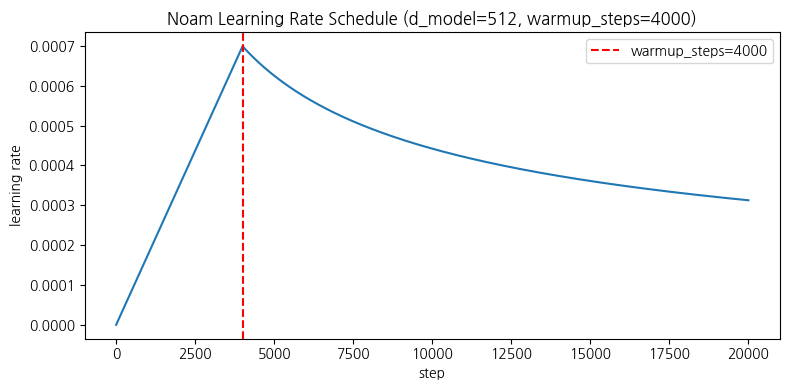

step 1 lr:     0.000000
최고점 lr:     0.000699  (step=4000, 정확히 warmup_steps와 일치)
step 20000 lr: 0.000313


In [17]:
class NoamScheduler:
    """논문 5.3절 학습률 스케줄. optimizer.step()과 함께 매 스텝 호출해서 lr을 직접 갱신합니다."""

    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0
        self._lr = 0

    def step(self):
        self.step_num += 1
        lr = self._compute_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        self._lr = lr

    def _compute_lr(self):
        step = self.step_num
        return (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))

    def get_last_lr(self):
        return self._lr


# ── 논문 Base 모델 기준 수치(d_model=512, warmup=4000)로 lr 곡선을 그려봅니다 ──
# (실습용 작은 모델이 아니라, 논문 원래 설정에서 곡선이 어떤 모양인지 보기 위한 별도 예시입니다)
dummy_param = nn.Parameter(torch.zeros(1))
dummy_optimizer = torch.optim.Adam([dummy_param], lr=0)
paper_scheduler = NoamScheduler(dummy_optimizer, d_model=512, warmup_steps=4000)

lr_history = []
for step in range(1, 20000):
    paper_scheduler.step()
    lr_history.append(paper_scheduler.get_last_lr())

plt.figure(figsize=(8, 4))
plt.plot(range(1, 20000), lr_history)
plt.axvline(x=4000, color='red', linestyle='--', label='warmup_steps=4000')
plt.xlabel("step")
plt.ylabel("learning rate")
plt.title("Noam Learning Rate Schedule (d_model=512, warmup_steps=4000)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"step 1 lr:     {lr_history[0]:.6f}")
print(f"최고점 lr:     {max(lr_history):.6f}  (step={lr_history.index(max(lr_history))+1}, 정확히 warmup_steps와 일치)")
print(f"step 20000 lr: {lr_history[-1]:.6f}")


## 12. 학습 루프 (Training Loop)

### Teacher Forcing이란?
디코더를 학습시킬 때는, 모델이 이전 스텝에서 직접 예측한(아직 부정확할 수 있는) 단어를 다음 입력으로 쓰는 대신, **정답 문장을 그대로 디코더 입력으로 사용**합니다. 이렇게 하면 학습이 훨씬 빠르고 안정적입니다. 이 기법을 **Teacher Forcing**이라고 부릅니다. (14절 추론에서는 정답이 없으므로, 모델이 직접 예측한 단어를 다음 입력으로 사용합니다 — 이 차이를 비교해서 보면 좋습니다.)

Teacher Forcing을 구현하려면 디코더의 "입력"과 "정답(라벨)"을 **한 칸씩 어긋나게** 만들어야 합니다.

```
tgt 전체           = [<sos>, 나는,  학생,  이다, <eos>, <pad>]
tgt_input  (입력)  = [<sos>, 나는,  학생,  이다, <eos>]          # 마지막 토큰 제외
tgt_output (정답)  = [나는,  학생,  이다, <eos>, <pad>]          # 첫 토큰(<sos>) 제외
```

`tgt_input`의 $i$번째 토큰까지 보고 `tgt_output`의 $i$번째 토큰(=바로 다음 단어)을 맞히도록 학습합니다. 예를 들어 `tgt_input`의 0번째(`<sos>`)만 보고 `tgt_output`의 0번째(`나는`)를 예측해야 하고, `tgt_input`의 0~1번째(`<sos>, 나는`)를 보고 `tgt_output`의 1번째(`학생`)를 예측해야 합니다 — 바로 이 "미래를 보면 안 된다"는 제약을 7절의 causal mask가 강제합니다.

### 한 스텝에서 일어나는 일
1. `tgt`를 `tgt_input`/`tgt_output`으로 자르고, 마스크를 만듭니다.
2. **Forward**: `model.encode(src)` -> `model.decode(tgt_input, enc_out)` -> `model.generator(...)`로 logit을 얻습니다.
3. **Loss**: logit에 `log_softmax`를 적용한 뒤, Label Smoothing Loss로 `tgt_output`과 비교합니다.
4. **Backward + 업데이트**: `loss.backward()`로 그래디언트를 계산하고, 학습률 스케줄러로 lr을 갱신한 뒤 `optimizer.step()`으로 가중치를 업데이트합니다.

토큰 1개당 평균 손실을 기록해두면(전체 손실을 배치 안의 실제 토큰 수로 나눔), 배치 크기나 문장 길이가 바뀌어도 손실 값을 일관되게 비교할 수 있습니다.


In [18]:
def train_one_epoch(model, data_loader, criterion, optimizer, scheduler, pad_idx, device):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for src, tgt in data_loader:
        src, tgt = src.to(device), tgt.to(device)

        # teacher forcing: 입력과 정답을 한 칸씩 어긋나게 사용
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        src_mask = make_padding_mask(src, pad_idx).to(device)
        tgt_mask = make_tgt_mask(tgt_input, pad_idx).to(device)

        # forward
        enc_out = model.encode(src, src_mask)
        dec_out = model.decode(tgt_input, enc_out, src_mask, tgt_mask)
        logits = model.generator(dec_out)   # (batch, tgt_len, vocab_size)

        # loss (label smoothing은 log-확률을 입력으로 받습니다)
        log_probs = F.log_softmax(logits, dim=-1)
        loss = criterion(
            log_probs.contiguous().view(-1, log_probs.size(-1)),
            tgt_output.contiguous().view(-1)
        )

        n_tokens = (tgt_output != pad_idx).sum().item()   # <pad>가 아닌 실제 토큰 개수

        optimizer.zero_grad()
        loss.backward()
        scheduler.step()     # lr을 먼저 갱신하고
        optimizer.step()     # 그 lr로 가중치 업데이트

        total_loss += loss.item()
        total_tokens += n_tokens

    return total_loss / total_tokens   # 토큰 1개당 평균 손실


## 13. 실제로 toy 데이터로 학습 실행

이제 모든 부품이 준비되었습니다. 모델, optimizer(논문 5.3절: Adam, $\beta_1=0.9, \beta_2=0.98, \epsilon=10^{-9}$), scheduler, loss를 만들고 학습을 돌려봅니다.

- optimizer의 초기 `lr=0`은 신경 쓰지 않아도 됩니다 — 매 스텝 `scheduler.step()`이 직접 lr을 계산해서 덮어쓰기 때문입니다.
- 32개 문장, CPU 환경 기준으로 400 epoch 정도면 1분 이내로 끝납니다. (실제 논문은 100,000~300,000 스텝, 8개 GPU로 12시간~3.5일이 걸립니다 — 16절에서 자세히 비교합니다.)


In [19]:
torch.manual_seed(SEED)   # 모델을 새로 초기화해서, 매번 같은 조건에서 학습이 시작되도록 함

model = Transformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF, num_layers=NUM_LAYERS,
    dropout=DROPOUT, max_len=MAX_LEN,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, d_model=D_MODEL, warmup_steps=WARMUP_STEPS)
criterion = LabelSmoothingLoss(vocab_size=len(tgt_vocab), pad_idx=PAD_IDX, smoothing=0.1)

N_EPOCHS = 400
loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    avg_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, PAD_IDX, device)
    loss_history.append(avg_loss)
    if epoch == 1 or epoch % 40 == 0:
        print(f"epoch {epoch:3d}/{N_EPOCHS} | loss(토큰당 평균) = {avg_loss:.4f} | lr = {scheduler.get_last_lr():.6f}")

print("\n학습 완료!")


epoch   1/400 | loss(토큰당 평균) = 3.8281 | lr = 0.001000


epoch  40/400 | loss(토큰당 평균) = 1.3411 | lr = 0.006988


epoch  80/400 | loss(토큰당 평균) = 0.9417 | lr = 0.004941


epoch 120/400 | loss(토큰당 평균) = 0.6718 | lr = 0.004034


epoch 160/400 | loss(토큰당 평균) = 0.6152 | lr = 0.003494


...

epoch 240/400 | loss(토큰당 평균) = 0.3968 | lr = 0.002853


epoch 280/400 | loss(토큰당 평균) = 0.2790 | lr = 0.002641


epoch 320/400 | loss(토큰당 평균) = 0.2398 | lr = 0.002471


epoch 360/400 | loss(토큰당 평균) = 0.1545 | lr = 0.002329


epoch 400/400 | loss(토큰당 평균) = 0.1711 | lr = 0.002210

학습 완료!


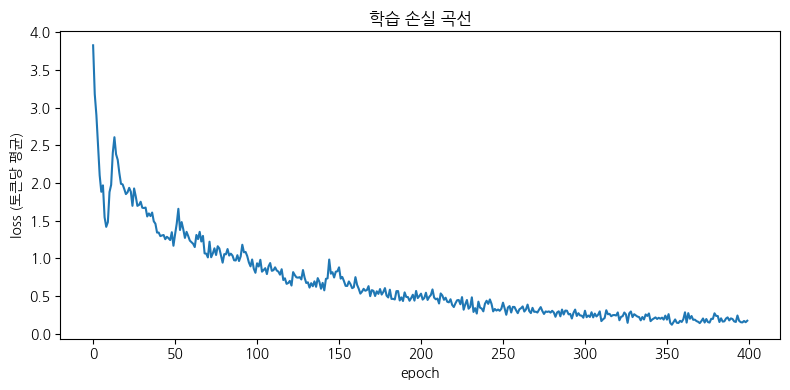

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss (토큰당 평균)")
plt.title("학습 손실 곡선")
plt.tight_layout()
plt.show()


손실이 꾸준히 줄어드는 것을 확인할 수 있습니다. 데이터가 32문장뿐이라 모델이 패턴을 거의 "암기"하는 수준까지 학습되는데, 이 사실을 다음 절(추론)에서 직접 확인해 봅니다.


## 14. 추론(Inference) — Greedy Decoding

### 학습(Teacher Forcing) vs. 추론(Autoregressive Generation)의 차이
학습할 때는 정답 문장을 알고 있으므로 디코더 입력 전체를 한 번에 넣을 수 있었습니다. 하지만 **실제로 새로운 문장을 번역할 때는 정답이 없습니다.** 그래서 디코더는 다음과 같이 **한 토큰씩** 스스로 만들어내야 합니다.

1. `<sos>` 토큰 하나로 디코더 입력을 시작합니다.
2. 지금까지 만든 토큰들을 디코더에 넣어 다음 토큰의 확률분포를 얻습니다.
3. 그중 확률이 가장 높은 토큰을 선택해서(이것이 바로 **Greedy**, "매 순간 가장 좋아 보이는 것을 선택") 디코더 입력 맨 뒤에 이어 붙입니다.
4. `<eos>` 토큰이 나오거나 최대 길이에 도달할 때까지 2~3을 반복합니다.

이때 인코더는 **딱 한 번만** 실행하면 됩니다 — 원문(`src`)은 바뀌지 않으므로 `enc_out`을 매 스텝 재사용합니다. (9절에서 `encode`/`decode`를 분리해 둔 이유가 바로 이것입니다.)

> 참고로 Greedy Decoding은 매 순간 1등만 선택하기 때문에 구현이 간단하지만, 문장 전체 기준에서는 최선이 아닐 수 있습니다. 실제 번역 시스템은 여러 후보를 동시에 추적하는 **Beam Search**를 더 많이 사용합니다 (16절에서 짧게 언급합니다).


In [21]:
def greedy_decode(model, src_sentence, src_vocab, tgt_vocab, max_len=20, device='cpu'):
    model.eval()   # dropout 등을 끄고 평가 모드로 전환

    # 1) 입력 문장을 인덱스로 바꾸고, 인코더를 한 번만 실행
    src_tokens = tokenize(src_sentence) + ['<eos>']
    src_ids = torch.tensor([[src_vocab.get(t, src_vocab['<unk>']) for t in src_tokens]]).to(device)
    src_mask = make_padding_mask(src_ids, src_vocab['<pad>']).to(device)

    with torch.no_grad():
        enc_out = model.encode(src_ids, src_mask)   # 이후 모든 스텝에서 재사용

    # 2) <sos> 하나로 디코더 입력을 시작
    tgt_ids = torch.tensor([[tgt_vocab['<sos>']]]).to(device)
    inv_tgt_vocab = {idx: tok for tok, idx in tgt_vocab.items()}   # 인덱스 -> 토큰 역사전

    for _ in range(max_len):
        tgt_mask = generate_causal_mask(tgt_ids.size(1)).to(device)
        with torch.no_grad():
            dec_out = model.decode(tgt_ids, enc_out, src_mask, tgt_mask)
            logits = model.generator(dec_out)

        # 가장 최근 위치(다음에 예측해야 할 토큰)의 logit만 사용해서, 확률이 가장 높은 토큰을 선택(greedy)
        next_token = logits[0, -1].argmax().item()
        tgt_ids = torch.cat([tgt_ids, torch.tensor([[next_token]]).to(device)], dim=1)

        if next_token == tgt_vocab['<eos>']:
            break

    # <sos>는 결과에서 제외하고, 끝에 <eos>가 있다면 제거한 뒤 문장으로 합침
    out_tokens = [inv_tgt_vocab[idx.item()] for idx in tgt_ids[0][1:]]
    if out_tokens and out_tokens[-1] == '<eos>':
        out_tokens = out_tokens[:-1]
    return ' '.join(out_tokens)


print("=== 학습 데이터에 '그대로' 있던 문장 (모델이 외운 패턴) ===")
for s in ["I like coffee", "He is a teacher"]:
    print(f"  {s:20s} -> {greedy_decode(model, s, src_vocab, tgt_vocab, device=device)}")

print("\n=== 학습 데이터에 없던, 새로운 조합의 문장 (일반화 테스트) ===")
for s in ["I like books", "She likes coffee"]:
    print(f"  {s:20s} -> {greedy_decode(model, s, src_vocab, tgt_vocab, device=device)}")


=== 학습 데이터에 '그대로' 있던 문장 (모델이 외운 패턴) ===


  I like coffee        -> ich mag kaffee
  He is a teacher      -> er ist ein lehrer

=== 학습 데이터에 없던, 새로운 조합의 문장 (일반화 테스트) ===
  I like books         -> er mag buecher
  She likes coffee     -> er mag musik


**학습 데이터에 정확히 있던 문장은 잘 번역**하지만, 단어를 살짝 재조합한 **새로운 문장에서는 틀리는 경우가 많습니다** (예: "I like books"는 학습 데이터에 없었고, 비슷한 "He likes books" / "I like coffee" 패턴이 뒤섞여 나옵니다). 이는 모델이나 코드가 잘못된 것이 아니라, **학습 데이터가 32문장뿐이라 "이해"가 아니라 "암기"에 가깝게 학습되었기 때문**입니다. 논문이 450만 개의 실제 문장 쌍으로 학습한 이유가 바로 여기에 있습니다 — 데이터가 많아질수록 모델은 패턴을 진짜로 "일반화"하기 시작합니다.


## 15. (보너스) Attention 가중치 시각화

논문은 Figure 3~5에서 학습된 모델의 attention 가중치를 시각화하여, 모델이 실제로 문법적/의미적으로 의미 있는 관계에 주목하고 있음을 보여줍니다. 우리 toy 모델로도 같은 방식의 시각화를 해볼 수 있습니다.

5절에서 만든 `MultiHeadAttention`은 `forward()`가 호출될 때마다 자기 자신의 `self.attn` 속성에 가장 최근 계산된 attention 가중치 `(batch, heads, seq_q, seq_k)`를 저장해 둡니다. 방금 `greedy_decode`로 번역을 마친 디코더의 **마지막 층, cross-attention** 가중치를 꺼내서, "번역문의 각 단어가 원문의 어느 단어를 더 많이 참고했는지" 살펴보겠습니다.


'I like coffee' -> 'ich mag kaffee'
attention 가중치 shape: torch.Size([1, 4, 4, 4])


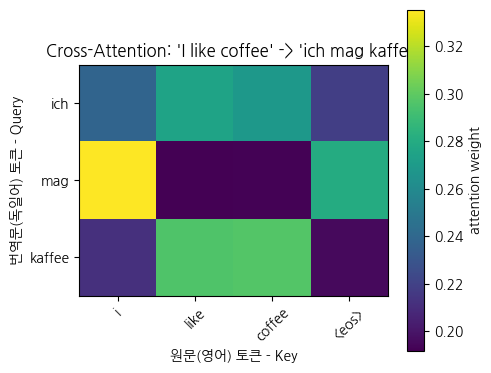

In [22]:
sentence = "I like coffee"
translation = greedy_decode(model, sentence, src_vocab, tgt_vocab, device=device)
print(f"'{sentence}' -> '{translation}'")

# 디코더 마지막 층의 cross-attention 가중치: (batch=1, num_heads, tgt_len, src_len)
attn_weights = model.decoder.layers[-1].cross_attn.attn
print("attention 가중치 shape:", attn_weights.shape)

# head 4개를 평균내서 하나의 그림으로 봅니다
avg_attn = attn_weights[0].mean(dim=0).detach().cpu().numpy()   # (tgt_len, src_len)

src_tokens_disp = tokenize(sentence) + ['<eos>']
tgt_tokens_disp = translation.split()

plt.figure(figsize=(5, 4))
plt.imshow(avg_attn[:len(tgt_tokens_disp)], cmap="viridis")
plt.xticks(range(len(src_tokens_disp)), src_tokens_disp, rotation=45)
plt.yticks(range(len(tgt_tokens_disp)), tgt_tokens_disp)
plt.xlabel("원문(영어) 토큰 - Key")
plt.ylabel("번역문(독일어) 토큰 - Query")
plt.title(f"Cross-Attention: '{sentence}' -> '{translation}'")
plt.colorbar(label="attention weight")
plt.tight_layout()
plt.show()


각 행(번역문 토큰 하나)의 색은 그 토큰을 만들 때 원문의 어떤 토큰을 더 많이 "참고"했는지를 나타내며, 한 행의 값을 모두 더하면 1이 됩니다 (4절에서 본 softmax의 성질입니다). 밝은 색일수록 더 많이 주목했다는 뜻입니다. toy 모델·toy 데이터 수준에서도 번역 단어와 원문 단어 사이에 그럴듯한 대응 관계가 나타나는지 직접 확인해 보세요.


## 16. 마무리 — toy 실습 vs. 논문의 실제 설정

이 노트북에서 만든 코드(`Transformer`, `MultiHeadAttention`, `PositionalEncoding` 등)는 **논문과 구조적으로 동일**합니다. 차이는 오직 "숫자"와 "데이터 양"입니다.

| 구분 | 이 노트북 (toy) | 논문 (Base 모델) |
|---|---|---|
| 데이터 | 직접 만든 영어-독일어 32문장 | WMT 2014 En-De, 약 450만 문장 쌍 |
| 토큰화 | 공백 기준 단어 단위 | BPE 서브워드, 공유 vocab 약 37,000개 |
| d_model / heads / layers | 128 / 4 / 2 | 512 / 8 / 6 |
| warmup_steps | 50 | 4,000 |
| 학습 시간 | CPU로 1분 내외 | 8 x P100 GPU로 약 12시간 (Big 모델은 3.5일) |
| 결과 | 학습 문장은 암기, 새 조합엔 약함 | WMT14 En-De 28.4 BLEU, En-Fr 41.8 BLEU (논문 보고 기준) |

### 더 나아가고 싶다면
1. **실제 데이터로 교체**: 2절 마지막의 참고 코드를 보고 `datasets` 라이브러리로 진짜 WMT 데이터를 받아 `pairs`를 교체해 보세요.
2. **서브워드 토큰화 도입**: 단어 단위 대신 SentencePiece나 Hugging Face `tokenizers`로 BPE를 학습시켜 `<unk>` 문제를 줄여보세요.
3. **하이퍼파라미터를 논문 값으로**: `D_MODEL=512, NUM_HEADS=8, NUM_LAYERS=6, D_FF=2048, WARMUP_STEPS=4000`으로 바꾸고, GPU 환경에서 더 오래 학습해 보세요. (코드 수정 없이 1절의 숫자만 바꾸면 됩니다.)
4. **Beam Search 구현**: 14절의 Greedy Decoding을, 매 스텝 가장 높은 확률 1개가 아니라 상위 k개의 후보를 동시에 추적하는 Beam Search로 바꿔보세요. 논문도 실제 평가에는 beam size 4의 Beam Search를 사용했습니다.
5. **BLEU 점수로 평가**: `sacrebleu` 같은 라이브러리로 번역 품질을 정량적으로 측정해 보세요.

축하합니다 — 이제 "Attention Is All You Need" 논문의 핵심 구성 요소를 모두 직접 구현하고, 학습부터 추론까지 전체 파이프라인을 한 번씩 돌려본 것입니다.
